<a href="https://colab.research.google.com/github/ram1014/colab_files/blob/main/Proyecto_Final_263165.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis predictivo de conjunto de datos: Intrusion Detection System

Alumno: Ramon Humberto Delgado Andrade

Matrícula: 263165

Profesor: Vicente García Jiménez

# Introducción

El conjunto a usar es el conjunto **Intrusion Detection System**, este conjunto de datos representa parámetros obtenidos por la herramienta Wireshark durante diferentes ataques cibernéticos a 4 dispositivos electrónicos conectados a una red.  

El conjunto de datos cuenta con 83 parámetros obtenidos por los ataques, y cuenta con un **target** que representa el tipo de ataque realizado. El propósito de este conjunto de datos es predecir por medio de los 83 parámetros el tipo de ataque cibernético realizado.

In [ ]:
#load Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from ucimlrepo import fetch_ucirepo
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

## Cargar el Conjunto de datos usando ucimlrepo

Usando Conjunto de datos localizado en:

https://archive.ics.uci.edu/dataset/942/rt-iot2022

Para la carga de los datos se utilizo el modulo de **ucimlrepo.fetch_ucirepo**

In [ ]:
# fetch dataset
rt_iot2022 = fetch_ucirepo(id=942)

rt_iot2022 = fetch_ucirepo(id=942)
X_orig = rt_iot2022.data.features
y_orig = rt_iot2022.data.targets

# data (as pandas dataframes)
X = rt_iot2022.data.features
y = rt_iot2022.data.targets

# metadata
#print(rt_iot2022.metadata)

# variable information
display(rt_iot2022.variables)
display(rt_iot2022.variables['missing_values'].value_counts())
display(X)
display(y)

,name,role,type,demographic,description,units,missing_values
0,id.orig_p,Feature,Integer,None,None,None,no
1,id.resp_p,Feature,Integer,None,None,None,no
2,proto,Feature,Categorical,None,None,None,no
3,service,Feature,Continuous,None,None,None,no
4,flow_duration,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...
80,fwd_init_window_size,Feature,Integer,None,None,None,no
81,bwd_init_window_size,Feature,Integer,None,None,None,no
82,fwd_last_window_size,Feature,Integer,None,None,None,no
83,Attack_type,Target,Categorical,None,None,None,no


missing_values
no    85
Name: count, dtype: int64

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,2.282415e+06,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,2.028307e+06,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,2.281904e+06,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,2.047288e+06,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,2.087657e+06,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,tcp,-,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123113,59247,64623,tcp,-,0.000007,1,1,0,0,144631.172400,...,6.914139e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123114,59247,64680,tcp,-,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123115,59247,65000,tcp,-,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024


,Attack_type
0,MQTT_Publish
1,MQTT_Publish
2,MQTT_Publish
3,MQTT_Publish
4,MQTT_Publish
...,...
123112,NMAP_XMAS_TREE_SCAN
123113,NMAP_XMAS_TREE_SCAN
123114,NMAP_XMAS_TREE_SCAN
123115,NMAP_XMAS_TREE_SCAN


In [ ]:
## Análisis de los datos

In [ ]:
display(X.info())
display('='*80)
display(y.info())
display('='*80)
columnas_numericas = X.select_dtypes(include=[np.number]).columns
display(X[columnas_numericas].describe().round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 83 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_header_size_tot       123117 non-null  i

None

'================================================================================'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Attack_type  123117 non-null  object
dtypes: object(1)
memory usage: 962.0+ KB


None

'================================================================================'

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000,123117.000,123117.000,123117.000,123117.000,123117.000,123117.000,123117.000,123117.000,123117.000,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000,123117.000,123117.000
mean,34639.259,1014.305,3.810,2.269,1.910,1.471,0.820,351806.328,351761.960,703568.288,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905,2739.776,751.648
std,19070.620,5256.372,130.005,22.337,33.018,19.635,32.294,370764.493,370801.485,741563.422,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.314,10018.849,6310.184
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000,0.000,0.000
25%,17702.000,21.000,0.000,1.000,1.000,1.000,0.000,74.544,72.889,149.087,...,9.540000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000,0.000,64.000
50%,37221.000,21.000,0.000,1.000,1.000,1.000,0.000,246723.765,246723.765,493447.529,...,4.053000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000,0.000,64.000
75%,50971.000,21.000,0.000,1.000,1.000,1.000,0.000,524288.000,524288.000,1048576.000,...,5.007000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000,0.000,64.000
max,65535.000,65389.000,21728.336,4345.000,10112.000,4345.000,10105.000,1048576.000,1048576.000,2097152.000,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000,65535.000,65535.000


### Tipos de ataques cibernéticos

Attack_type               
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

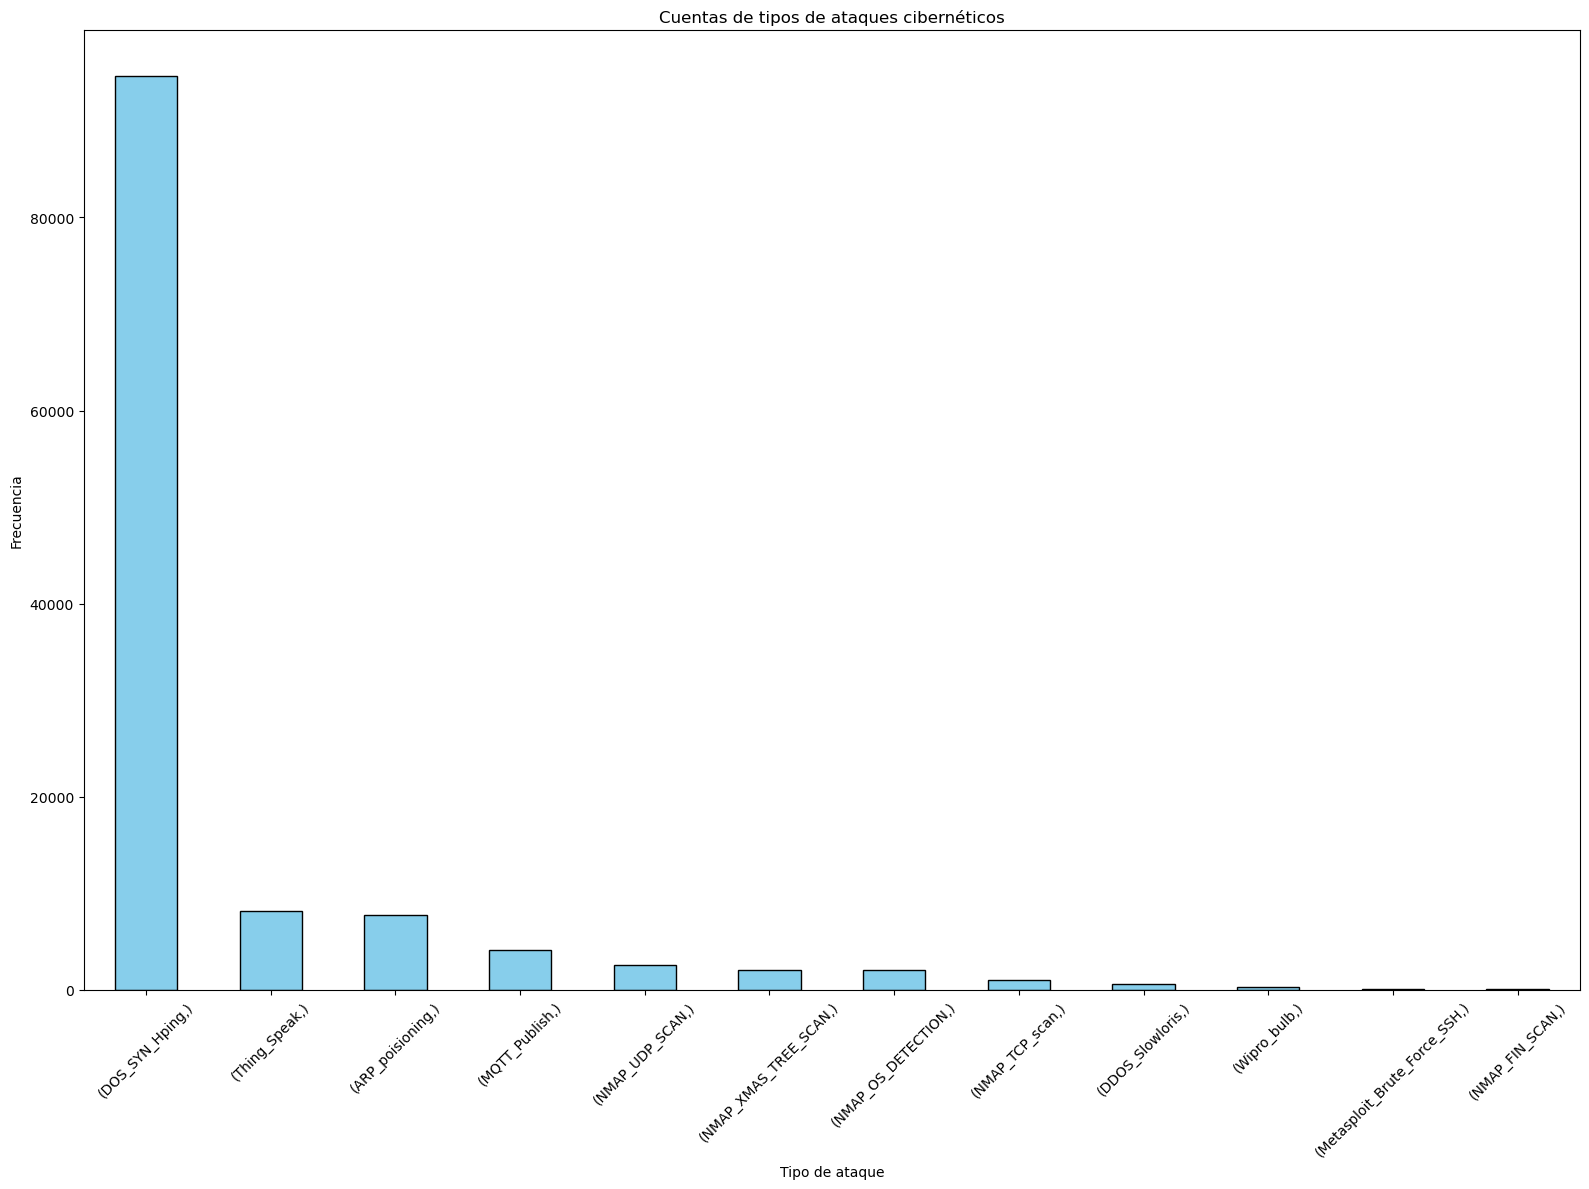

In [ ]:
attack_counts = y.value_counts()

display(attack_counts)

# crear la grafica para las cuentas de los posibles ataques
plt.figure(figsize=(16, 12))
attack_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cuentas de tipos de ataques cibernéticos')
plt.xlabel('Tipo de ataque')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Desbalance de las etiquetas de clase
Como se puede observar en la gráfica anterior se ve un gran desbalance en las etiquetas de clase, especialmente la etiqueta "DOS_SYN_Hping" tiene una cuenta de ~94 mil registros mientras que las demás categorías tienen cuentas menores a 10 mil; inclusive hay etiquetas con tan solo un par de registros.

En los siguientes análisis se considerará hacer un SMOTE para el balanceo de etiquetas.

In [ ]:
## Seleccionar solo las columnas numéricas
#columnas_numericas = X.select_dtypes(include=[np.number]).columns
#
## Calcular el número de filas y columnas para el subplot
#n = len(columnas_numericas)
#ncols = 2
#nrows = math.ceil(n/ncols)
## Crear la figura y los subplots
#fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
#fig.suptitle('Distribución de Variables Numéricas', fontsize=16)
#
## Aplanar el array de ejes en caso de que sea 2D
#axes = axes.flatten() if n > 3 else [axes]
#
## Crear histogramas para cada variable numérica
#for i, col in enumerate(columnas_numericas):
#    ax = axes[i]
#    X[col].hist(ax=ax, bins=50, edgecolor='black',color='slateblue')
#    ax.set_title(f'Distribución de {col}')
#    ax.set_xlabel(col)
#    ax.set_ylabel('Frecuencia')
#
## Ocultar subplots vacíos si los hay
#for j in range(i+1, len(axes)):
#    fig.delaxes(axes[j])
#
#plt.tight_layout()
#plt.show()

In [ ]:
#boxplots
# Configurar el tamaño de la figura
#n = len(columnas_numericas)
#ncols = 2
#nrows = math.ceil(n/ncols)
#plt.figure(figsize=(15, 100))
#
## Crear boxplots para cada columna numérica
#for i, col in enumerate(columnas_numericas, 1):
#    plt.subplot(nrows, ncols, i)  # 2 filas, 4 columnas de subplots
#    sns.boxplot(x=X[col])
#    plt.title(f'Boxplot de {col}')
#plt.tight_layout()
#plt.show()

### Cuentas de valores categóricos

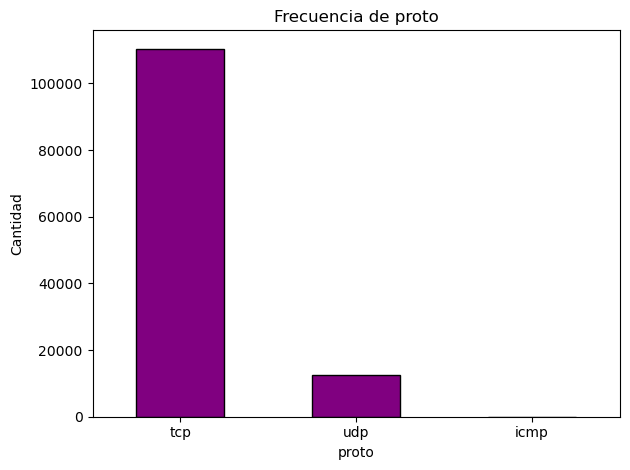

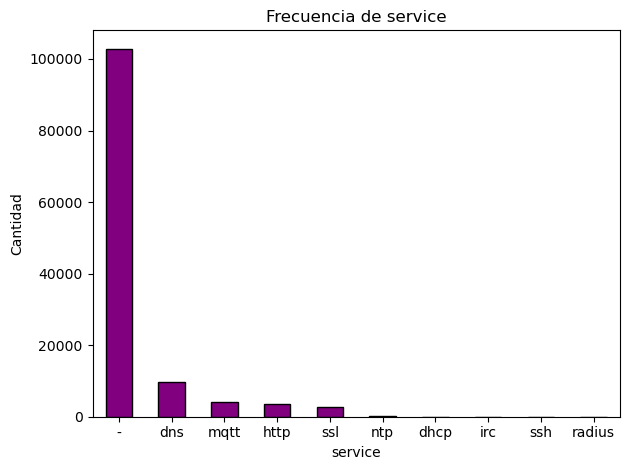

In [ ]:
#plot category values

col_categoric = ['proto', 'service']

# Crear histogramas para cada variable numérica
for i, col in enumerate(col_categoric):
    frec = X[col].value_counts()
    frec.plot(kind='bar', color='purple', edgecolor='black')
    plt.title('Frecuencia de ' + col)
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Análisis predictivo

Para el análisis predictivo se utilizará el modelado de Random Forest y un Árbol de decisiones.
La razón para usar estos modelos es que después del análisis de datos anteriores estos podrían dar buenos resultados debido al uso de columnas mayormente numéricas.

Consideraciones para realizar el random forest:

* Convertir las dos columnas categóricas a numéricas (**proto** y **service**). Se usará LabelEncoder debido a que son pocas las diferentes categorías.
* Después del modelado se realizará un SMOTE para comparar los resultados.

Consideraciones para realizar el Arbol de decisiones:

* Después del modelado se realizará un SMOTE para comparar los resultados.

In [ ]:
X = pd.DataFrame()
y = pd.DataFrame()

encoder = LabelEncoder()
for col in X_orig.columns:
    if(col == 'proto' or col == 'service'):
        X[col] = encoder.fit_transform(X_orig[col])
    else:
        X[col] = X_orig[col]
#y['Attack_type'] = encoder.fit_transform(y_orig['Attack_type'])
y['Attack_type'] = y_orig['Attack_type']
display(X)
display(y)


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,1,5,32.011598,9,5,3,3,0.281148,...,2.282415e+06,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502
1,51143,1883,1,5,31.883584,9,5,3,3,0.282277,...,2.028307e+06,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502
2,44761,1883,1,5,32.124053,9,5,3,3,0.280164,...,2.281904e+06,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502
3,60893,1883,1,5,31.961063,9,5,3,3,0.281593,...,2.047288e+06,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502
4,51087,1883,1,5,31.902362,9,5,3,3,0.282111,...,2.087657e+06,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,1,0,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123113,59247,64623,1,0,0.000007,1,1,0,0,144631.172400,...,6.914139e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123114,59247,64680,1,0,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024
123115,59247,65000,1,0,0.000006,1,1,0,0,167772.160000,...,5.960464e+00,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024


,Attack_type
0,MQTT_Publish
1,MQTT_Publish
2,MQTT_Publish
3,MQTT_Publish
4,MQTT_Publish
...,...
123112,NMAP_XMAS_TREE_SCAN
123113,NMAP_XMAS_TREE_SCAN
123114,NMAP_XMAS_TREE_SCAN
123115,NMAP_XMAS_TREE_SCAN


## Aprendizaje usando RandomForest

Accuracy Random Forest: 0.9978611652588261
                            precision    recall  f1-score   support

            ARP_poisioning       0.98      0.99      0.99      2306
            DDOS_Slowloris       0.99      0.97      0.98       154
             DOS_SYN_Hping       1.00      1.00      1.00     28409
              MQTT_Publish       1.00      1.00      1.00      1273
Metasploit_Brute_Force_SSH       1.00      0.64      0.78        11
             NMAP_FIN_SCAN       1.00      0.86      0.92         7
         NMAP_OS_DETECTION       1.00      1.00      1.00       622
             NMAP_TCP_scan       1.00      1.00      1.00       319
             NMAP_UDP_SCAN       0.99      0.99      0.99       750
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       582
               Thing_Speak       0.99      0.99      0.99      2424
                Wipro_bulb       0.99      0.94      0.96        79

                  accuracy                           1.00     36936
   

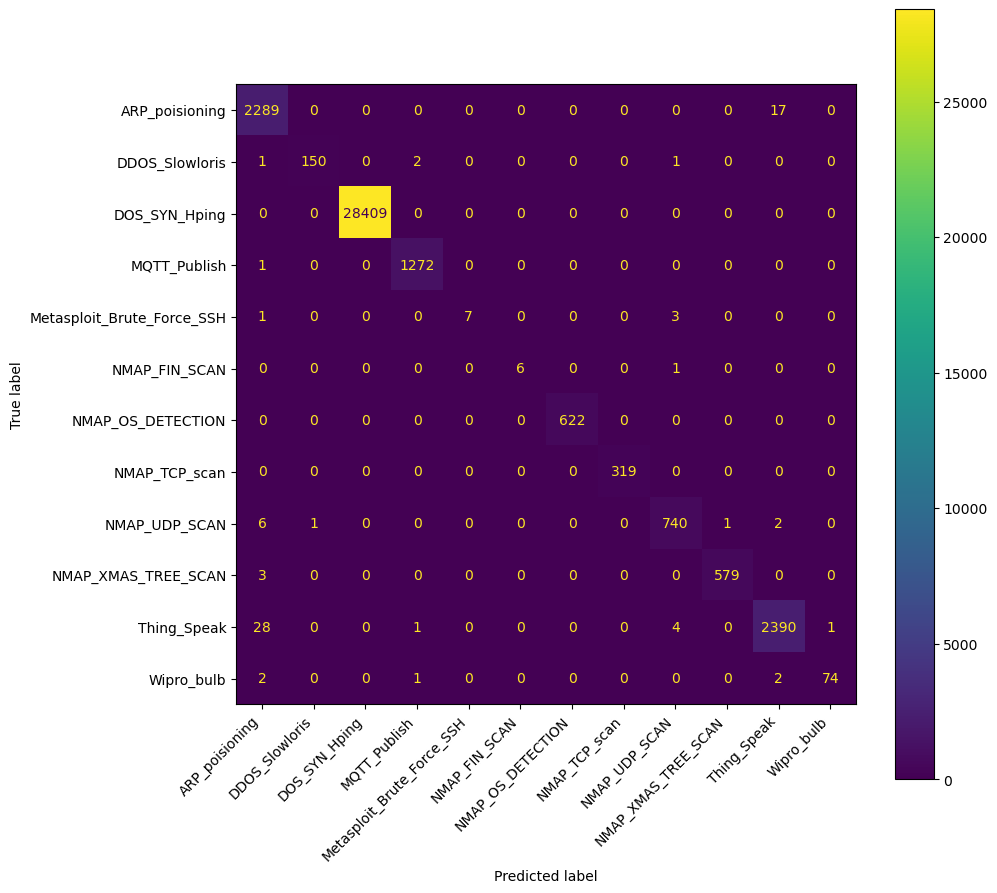

In [ ]:
# Crear divisiones para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Usar modelo de random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.values.ravel())

# Evaluar
y_pred = rf.predict(X_test)
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()

### Usar SMOTE para RandomForest


Como parte del balanceo de clases, se uniran las categorias DDOS_Slowloris, Wipro_bulb,Metasploit_Brute_Force_SSH en una sola categoria, esto en adicion a realizar el SMOTE.


In [ ]:
#Para las clases con menor frecuencia, juntarlas en una sola que sea "OTHER"
y['Attack_type'] = y_orig['Attack_type'].replace(['DDOS_Slowloris', 'Wipro_bulb','Metasploit_Brute_Force_SSH'], 'Other')
attack_counts = y.value_counts()

display(attack_counts)


Attack_type        
DOS_SYN_Hping          94659
Thing_Speak             8108
ARP_poisioning          7750
MQTT_Publish            4146
NMAP_UDP_SCAN           2590
NMAP_XMAS_TREE_SCAN     2010
NMAP_OS_DETECTION       2000
NMAP_TCP_scan           1002
Other                    824
NMAP_FIN_SCAN             28
Name: count, dtype: int64

Accuracy Random Forest: 0.9976716482564436
                     precision    recall  f1-score   support

     ARP_poisioning       0.98      0.99      0.99      2306
      DOS_SYN_Hping       1.00      1.00      1.00     28409
       MQTT_Publish       1.00      1.00      1.00      1273
      NMAP_FIN_SCAN       1.00      0.86      0.92         7
  NMAP_OS_DETECTION       1.00      1.00      1.00       622
      NMAP_TCP_scan       1.00      1.00      1.00       319
      NMAP_UDP_SCAN       0.98      0.98      0.98       750
NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       582
              Other       0.97      0.96      0.97       244
        Thing_Speak       0.99      0.99      0.99      2424

           accuracy                           1.00     36936
          macro avg       0.99      0.98      0.98     36936
       weighted avg       1.00      1.00      1.00     36936

[[ 2277     0     0     0     0     0     3     0     1    25]
 [    0 28409     0     0     0     0

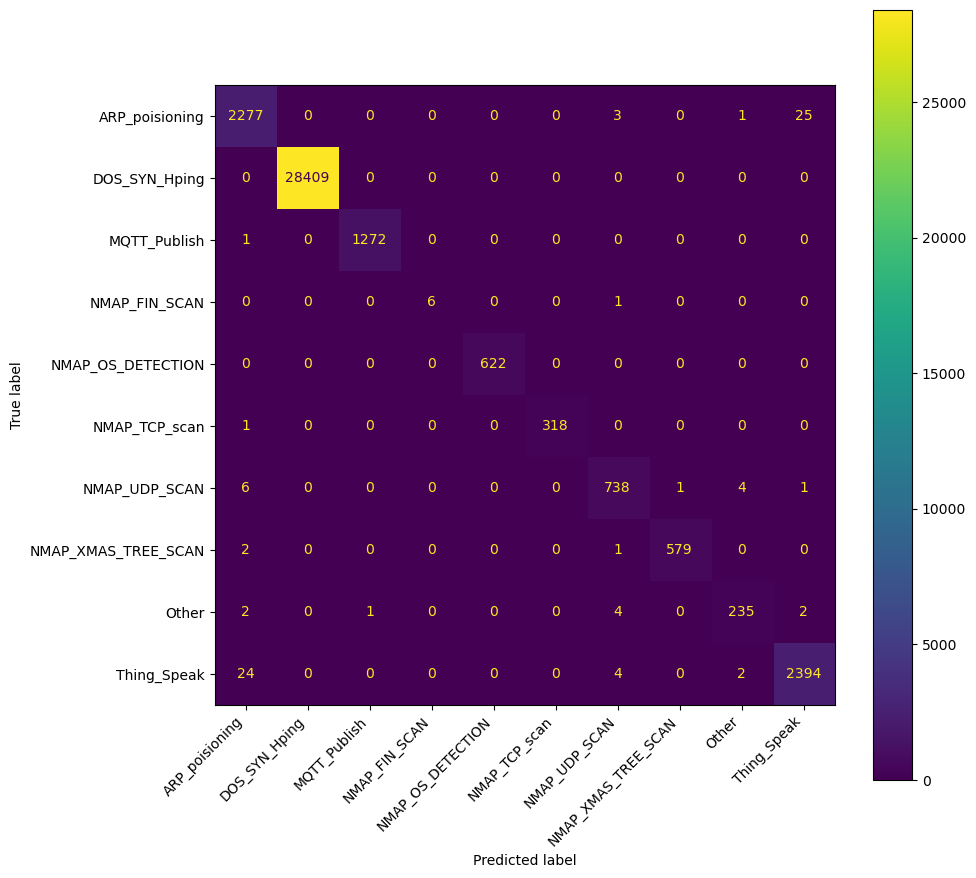

In [ ]:

# Crear divisiones para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_trainr, y_trainr = smote.fit_resample(X_train, y_train)

# Usar modelo de random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_trainr, y_trainr.values.ravel())

# Evaluar
y_pred = rf.predict(X_test)
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()


### Conclusiones
El modelo sin SMOTE tiene muy buenos resultados, pero para la etiqueta **Metasploit_Brute_Force_SSH** los métricos son bajos debido a la poca frecuencia de la misma.


Al juntar los datos con menor frecuencia a una sola categoría ayuda a mejorar la predicción en la combinación de esas 3 categorías.

Con los resultados obtenidos, se recomendaría realizar un análisis de los datos y ver si son reales, ya que se obtienen niveles muy altos en los métricos con accuracy iguales a 1 en algunos casos. Más pruebas serían necesarias para validar que los resultados son verdaderos.

## Aprendizaje usando arbol de desiciones

In [ ]:
X = pd.DataFrame()
y = pd.DataFrame()

for col in X_orig.columns:
    if(col == 'proto' or col == 'service'):
        X[col] = encoder.fit_transform(X_orig[col])
    else:
        X[col] = X_orig[col]
#y['Attack_type'] = encoder.fit_transform(y_orig['Attack_type'])
y['Attack_type'] = y_orig['Attack_type']

# Crear divisiones para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
train_accuracies = []
test_accuracies = []
depths = range(1, 10)

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

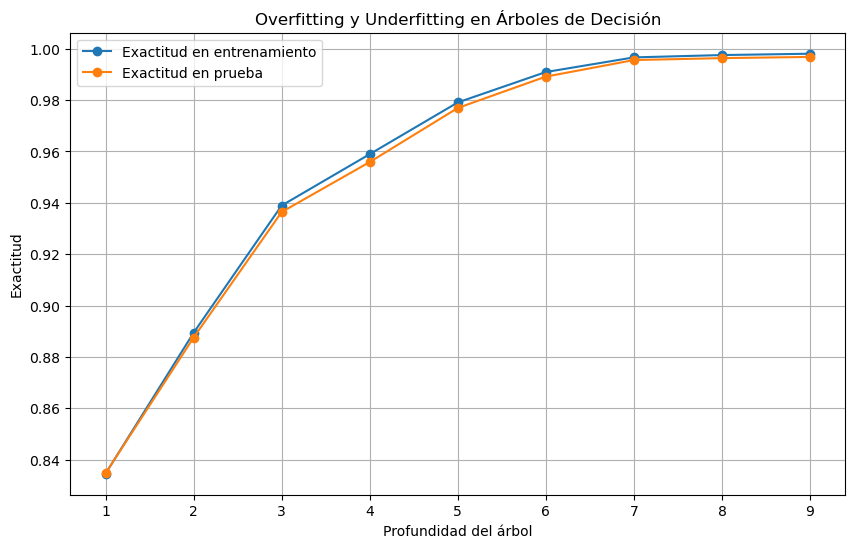

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_accuracies, label='Exactitud en entrenamiento', marker='o')
plt.plot(depths, test_accuracies, label='Exactitud en prueba', marker='o')
plt.xlabel('Profundidad del árbol')
plt.ylabel('Exactitud')
plt.title('Overfitting y Underfitting en Árboles de Decisión')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 2. Definir el modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'max_depth': range(5,51),
    'min_samples_split': [2, 4, 6]
}

# 4. Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configurar GridSearchCV con Strafified
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# 6. Ajustar el modelo
grid_search.fit(X, y)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)